In [58]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, CSVLogger
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request
import gzip
import shutil
from gensim.models import KeyedVectors

print("--- STEP 1: DEEGENKA WAA DIFAAC ---")
print(f"TensorFlow Version: {tf.__version__}")

# Abuurista masiirka rasmiga ah ee kaydka logs-ka iyo embeddings-ka
os.makedirs("models/deep_learning/training_logs", exist_ok=True)
os.makedirs("models/deep_learning/embeddings", exist_ok=True)

print("✓ Galkii models/deep_learning/training_logs/ waa la abuuray!")

--- STEP 1: DEEGENKA WAA DIFAAC ---
TensorFlow Version: 2.21.0
✓ Galkii models/deep_learning/training_logs/ waa la abuuray!


In [59]:
print("--- STEP 2: SHUBIDDA XOGTA GITHUB IYO QAYBINTA ---")

# Link-gii aad isoo siisay oo loo beddelay RAW si Pandas u aqriso
raw_github_url = "https://raw.githubusercontent.com/Eng-Muscab/SOMALI-NLP-RESEARCH/b5c2209bb583417019ad6f59a1dbae5bd4379b2f/data/annotations/labeled_ai_human_final.csv"

print("Xogta ayaa laga soo dejinayaa GitHub... Fadlan sug...")
df = pd.read_csv(raw_github_url)

# Hubi magacyada tiirarka (Columns) si aan u hubino inay yihiin 'text' iyo 'label'
print(f"Tiirarka xogta ku jira waa: {list(df.columns)}")

# Ka nadiifi safaf kasta oo madhan
df = df.dropna(subset=['Text', 'Label'])

# U kala qaybi xogta nadiifka ah qoraal (X) iyo calaamad (y)
X_raw = df['Text'].values
y_raw = df['Label'].values

# U kala jebi 80% Train (Tababar) iyo 20% Test (Tijaabo)
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

print(f"\n✓ Xogta guud: {len(df)} saf.")
print(f"✓ Xogta Tababarka (Train Set): {len(X_train_raw)} saf.")
print(f"✓ Xogta Tijaabada (Test Set): {len(X_test_raw)} saf.")

--- STEP 2: SHUBIDDA XOGTA GITHUB IYO QAYBINTA ---
Xogta ayaa laga soo dejinayaa GitHub... Fadlan sug...
Tiirarka xogta ku jira waa: ['Text', 'Label']

✓ Xogta guud: 5897 saf.
✓ Xogta Tababarka (Train Set): 4717 saf.
✓ Xogta Tijaabada (Test Set): 1180 saf.


In [61]:


print("--- STEP 3: TOKENIZATION IYO IS-GUNTIDDA FASTTEXT (FIXED) ---")

MAX_WORDS = 20000  # Inta eray ee ugu caansan xogtaada
MAX_LEN = 150      # Dhererka qoraal kasta (150 eray)

# ==========================================
# XALKA CILADDA: U beddel 'HUMAN' -> 0 iyo 'AI' -> 1
# ==========================================
# Ka tirtir wixii fariin madhan ah haddii ay jiraan mar kale
y_train_mapped = np.array([0 if str(label).strip().upper() == 'HUMAN' else 1 for label in y_train_raw], dtype=np.float32)
y_test_mapped = np.array([0 if str(label).strip().upper() == 'HUMAN' else 1 for label in y_test_raw], dtype=np.float32)

# ==========================================
# 1. TOKENIZATION & PADDING
# ==========================================
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_raw)

X_train_seq = tokenizer.texts_to_sequences(X_train_raw)
X_test_seq = tokenizer.texts_to_sequences(X_test_raw)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

# Hubi in noocyada xogtu ay yihiin Numpy nadiif ah
X_train_pad = np.array(X_train_pad, dtype=np.int32)
X_test_pad = np.array(X_test_pad, dtype=np.int32)
y_train = y_train_mapped
y_test = y_test_mapped

vocab_size = min(len(tokenizer.word_index) + 1, MAX_WORDS)
print(f"✓ Tokenization waa diyaar. Xajmiga Qaamuuska (Vocab Size): {vocab_size}")
print(f"✓ Calaamadihii 'HUMAN'/'AI' waxaa loo beddelay 0 iyo 1!")


# ==========================================
# 2. SOO DEJINTA FASTTEXT SOMALI VECTORS
# ==========================================
fasttext_dir = "models/deep_learning/embeddings"
os.makedirs(fasttext_dir, exist_ok=True)

gz_path = os.path.join(fasttext_dir, "cc.so.300.vec.gz")
vec_path = os.path.join(fasttext_dir, "cc.so.300.vec")
url = "https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.so.300.vec.gz"

if not os.path.exists(gz_path):
    print("FastText Somali Vectors ayaa la soo dejinayaa (cc.so.300.vec.gz)... Fadlan sug...")
    urllib.request.urlretrieve(url, gz_path)
    print("✓ Soo dejintii GZ faylka waa dhammaatay!")

if not os.path.exists(vec_path):
    print("Faylka ayaa la kala bixinayaa (Unzipping)...")
    with gzip.open(gz_path, 'rb') as f_in:
        with open(vec_path, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)
    print("✓ Kala bixintii faylka waa dhammaatay!")


# ==========================================
# 3. RARIDDA VECTORS-KA IYO SAMAYNTA MATRIX-KA
# ==========================================
print("FastText Vectors-ka ayaa loo rarayaa Memory-ga (Kombuyuutarka)...")
fasttext_model = KeyedVectors.load_word2vec_format(vec_path, binary=False, limit=50000)

EMBEDDING_DIM = 300  
embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))

hits = 0
misses = 0

for word, i in tokenizer.word_index.items():
    if i < vocab_size:
        if word in fasttext_model:
            embedding_matrix[i] = fasttext_model[word]
            hits += 1
        else:
            embedding_matrix[i] = np.random.normal(scale=0.6, size=(EMBEDDING_DIM,))
            misses += 1

print("\n--- SHAXDA FASTTEXT EMBEDDING ---")
print(f"✓ Matrix-ka qaabkiisa (Shape): {embedding_matrix.shape}")
print(f" Erayada FastText-ka laga helay: {hits}")
print(f" Erayada aan ku jirin FastText (Randomized): {misses}")

--- STEP 3: TOKENIZATION IYO IS-GUNTIDDA FASTTEXT (FIXED) ---
✓ Tokenization waa diyaar. Xajmiga Qaamuuska (Vocab Size): 20000
✓ Calaamadihii 'HUMAN'/'AI' waxaa loo beddelay 0 iyo 1!
FastText Vectors-ka ayaa loo rarayaa Memory-ga (Kombuyuutarka)...

--- SHAXDA FASTTEXT EMBEDDING ---
✓ Matrix-ka qaabkiisa (Shape): (20000, 300)
 Erayada FastText-ka laga helay: 9859
 Erayada aan ku jirin FastText (Randomized): 10140


In [63]:
print("--- STEP 4: DHISIDDA IYO TABABARKA BILSTM + FASTTEXT ---")

# 1. Naqshadaynta Moodeelka BiLSTM
model = Sequential([
    # Lakabka Embedding-ka oo sita miisaankii FastText ee aan Step 3 ku diyaarinay
    Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        trainable=False  # Waxaan u xireynaa si uu u dhowro aqoontii FastText
    ),
    # Bidirectional LSTM oo wadata Dropout si looga hortago Overfitting (Dhalanteedka)
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.5),
    
    # Dense Layers ee go'aanka dhabta ah kala saaraya
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Sigmoid maadaama ay tahay Binary Classification (0 ama 1)
])

# 2. Compile-garedhita Moodeelka
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# 3. Diyaarinta Callbacks (Early Stopping iyo CSVLogger rasmiga ah)
log_dir = "models/deep_learning/training_logs"
log_path = os.path.join(log_dir, "bilstm_fasttext_training_log.csv")

callbacks_list = [
    # Haddii Validation Loss uu hagaagi waayo 3 Epochs, jooji tababarka si aad waqtiga u badbaadiso
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    # U kaydi Epoch kasta natiujadiisa faylka CSV ah si nidaamsan
    CSVLogger(log_path, append=False)
]

# 4. Bilaabidda Tababarka Rasmiga ah
print("\nTababarkii wuxuu ku bilaabanayaa si toos ah...")
history = model.fit(
    X_train_pad, y_train,
    epochs=10,  # Waxaad u deyn kartaa 10, EarlyStopping ayaa qabanaya haddii uu barashada dhameysto
    batch_size=32,
    validation_data=(X_test_pad, y_test),
    callbacks=callbacks_list,
    verbose=1
)

print(f"\n✓ Guul! Tababarku waa dhammaaday, faylkii log-kana waxaa lagu keydiyay: {log_path}")

--- STEP 4: DHISIDDA IYO TABABARKA BILSTM + FASTTEXT ---


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)             │ ?                           │       6,000,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_11 (Bidirectional)     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_22 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_23 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,000,000 (22.89 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 6,000,000 (22.89 MB)


Tababarkii wuxuu ku bilaabanayaa si toos ah...
Epoch 1/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 34s 163ms/step - accuracy: 0.6625 - loss: 0.6140 - val_accuracy: 0.7246 - val_loss: 0.5511
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 23s 155ms/step - accuracy: 0.7912 - loss: 0.4703 - val_accuracy: 0.7831 - val_loss: 0.4528
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 25s 171ms/step - accuracy: 0.8306 - loss: 0.3993 - val_accuracy: 0.8068 - val_loss: 0.4143
Epoch 4/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 24s 165ms/step - accuracy: 0.8609 - loss: 0.3434 - val_accuracy: 0.8008 - val_loss: 0.4084
Epoch 5/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 23s 157ms/step - accuracy: 0.8889 - loss: 0.2851 - val_accuracy: 0.7966 - val_loss: 0.4578
Epoch 6/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 24s 160ms/step - accuracy: 0.9054 - loss: 0.2408 - val_accuracy: 0.7966 - val_loss: 0.4671
Epoch 7/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 23s 155ms/step - accuracy: 0.9230 - loss: 0.2044 - val_accuracy: 0.8000 - val_loss: 0.5223

✓ Guul! Tababarku waa dhammaaday, 

In [64]:
from gensim.models import Word2Vec

print("--- STEP 6 (PART 2): TABABARKA WORD2VEC SOMALI EMBEDDING ---")

# 1. U diyaari qoraalada qaab liis erayo ah (Tokenized sentences for Gensim)
print("Xogtii qoraalka ahayd ee tababarka waxaa loo kala jabinayaa erayo...")
train_sentences = [str(text).split() for text in X_train_raw]

# 2. Tababar moodeelka Word2Vec oo custom ah
WORD2VEC_DIM = 300  # Waxaan ka dhigaynaa 300 dhererkiisa si uu ula mid noqdo FastText
print("Word2Vec moodeelka ayaa si toos ah loogu tababarayaa xogtaada...")
w2v_model = Word2Vec(
    sentences=train_sentences, 
    vector_size=WORD2VEC_DIM, 
    window=5, 
    min_count=1, 
    workers=4
)

# 3. Samaynta Word2Vec Embedding Matrix-ka BiLSTM
w2v_embedding_matrix = np.zeros((vocab_size, WORD2VEC_DIM))
w2v_hits = 0
w2v_misses = 0

for word, i in tokenizer.word_index.items():
    if i < vocab_size:
        if word in w2v_model.wv:
            w2v_embedding_matrix[i] = w2v_model.wv[word]
            w2v_hits += 1
        else:
            w2v_embedding_matrix[i] = np.random.normal(scale=0.6, size=(WORD2VEC_DIM,))
            w2v_misses += 1

print("\n--- SHAXDA WORD2VEC EMBEDDING ---")
print(f"✓ Word2Vec Matrix shape: {w2v_embedding_matrix.shape}")
print(f" Erayada Word2Vec laga helay: {w2v_hits}")
print(f" Erayada aan ku jirin (Randomized): {w2v_misses}")

--- STEP 6 (PART 2): TABABARKA WORD2VEC SOMALI EMBEDDING ---
Xogtii qoraalka ahayd ee tababarka waxaa loo kala jabinayaa erayo...
Word2Vec moodeelka ayaa si toos ah loogu tababarayaa xogtaada...

--- SHAXDA WORD2VEC EMBEDDING ---
✓ Word2Vec Matrix shape: (20000, 300)
 Erayada Word2Vec laga helay: 16723
 Erayada aan ku jirin (Randomized): 3276


In [65]:
print("--- STEP 6 (PART 2): DHISIDDA IYO TABABARKA BILSTM + WORD2VEC ---")

# 1. Naqshadaynta Moodeelka BiLSTM (Word2Vec Version)
model_w2v = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=WORD2VEC_DIM,
        weights=[w2v_embedding_matrix],
        input_length=MAX_LEN,
        trainable=False  # Waxaan u xireynaa si uu u dhowro aqoontii Word2Vec
    ),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# 2. Compile moodeelka
model_w2v.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_w2v.summary()

# 3. Masiirka logs-ka rasmiga ah ee Word2Vec
w2v_log_path = "models/deep_learning/training_logs/bilstm_word2vec_training_log.csv"

w2v_callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    CSVLogger(w2v_log_path, append=False)
]

# 4. Bilaabidda Tababarka
print("\nTababarkii BiLSTM + Word2Vec wuxuu ku bilaabanayaa si toos ah...")
history_w2v = model_w2v.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_pad, y_test),
    callbacks=w2v_callbacks,
    verbose=1
)

print(f"\n✓ Guul! Tababarkii Word2Vec waa dhammaaday rami ahaan!")
print(f" Faylkii log-ka waxaa lagu keydiyay: {w2v_log_path}")

--- STEP 6 (PART 2): DHISIDDA IYO TABABARKA BILSTM + WORD2VEC ---


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_12 (Embedding)             │ ?                           │       6,000,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_12 (Bidirectional)     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_24 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_24 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_25 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,000,000 (22.89 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 6,000,000 (22.89 MB)


Tababarkii BiLSTM + Word2Vec wuxuu ku bilaabanayaa si toos ah...
Epoch 1/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 42s 198ms/step - accuracy: 0.7469 - loss: 0.5001 - val_accuracy: 0.8254 - val_loss: 0.3494
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 25s 169ms/step - accuracy: 0.7089 - loss: 0.5599 - val_accuracy: 0.8568 - val_loss: 0.3784
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 27s 184ms/step - accuracy: 0.8372 - loss: 0.3934 - val_accuracy: 0.8788 - val_loss: 0.3024
Epoch 4/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 27s 179ms/step - accuracy: 0.8823 - loss: 0.2990 - val_accuracy: 0.8864 - val_loss: 0.2590
Epoch 5/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 25s 166ms/step - accuracy: 0.8980 - loss: 0.2630 - val_accuracy: 0.8958 - val_loss: 0.2488
Epoch 6/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 25s 165ms/step - accuracy: 0.9050 - loss: 0.2295 - val_accuracy: 0.9102 - val_loss: 0.2179
Epoch 7/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 25s 171ms/step - accuracy: 0.9137 - loss: 0.2040 - val_accuracy: 0.9161 - val_loss: 0.2157
Epoch 8/10
148/14

--- STEP 5: QIIMAYNTA IYO ISBARBARDHIGGA MOODEELADA (EVALUATION) ---
Moodeelada ayaa saadaalinaya xogta tijaabada...
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step

📊 PERFORMANCE REPORT: BiLSTM + FastText
              precision    recall  f1-score   support

       HUMAN       0.78      0.83      0.80       582
          AI       0.82      0.77      0.80       598

    accuracy                           0.80      1180
   macro avg       0.80      0.80      0.80      1180
weighted avg       0.80      0.80      0.80      1180


📊 PERFORMANCE REPORT: BiLSTM + Word2Vec
              precision    recall  f1-score   support

       HUMAN       0.91      0.91      0.91       582
          AI       0.91      0.91      0.91       598

    accuracy                           0.91      1180
   macro avg       0.91      0.91      0.91      1180
weighted avg       0.91      0.91      0.91      1180



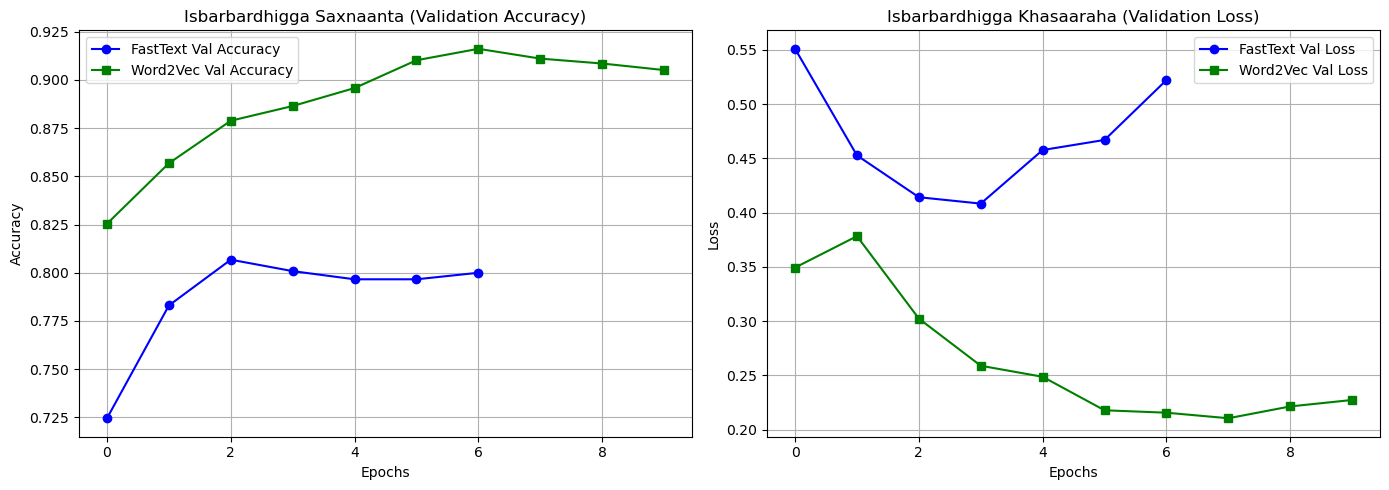

In [66]:
print("--- STEP 5: QIIMAYNTA IYO ISBARBARDHIGGA MOODEELADA (EVALUATION) ---")

# 1. Saadaalinta Xogta Tijaabada (Predictions)
print("Moodeelada ayaa saadaalinaya xogta tijaabada...")
preds_fasttext = model.predict(X_test_pad)
preds_word2vec = model_w2v.predict(X_test_pad)

# U beddel probabilities-ka 0 ama 1 (Threshold = 0.5)
y_pred_ft = (preds_fasttext > 0.5).astype(int).flatten()
y_pred_w2v = (preds_word2vec > 0.5).astype(int).flatten()

# 2. Daabacaadda Classification Report ee Labada Moodeel
target_names = ['HUMAN', 'AI']

print("\n==================================================")
print("📊 PERFORMANCE REPORT: BiLSTM + FastText")
print("==================================================")
print(classification_report(y_test, y_pred_ft, target_names=target_names))

print("\n==================================================")
print("📊 PERFORMANCE REPORT: BiLSTM + Word2Vec")
print("==================================================")
print(classification_report(y_test, y_pred_w2v, target_names=target_names))


# 3. Soo Saarista Jaantusyada Isbarbardhigga (Plotting Training Curves)
plt.figure(figsize=(14, 5))

# Jaantuska Labada Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['val_accuracy'], label='FastText Val Accuracy', color='blue', marker='o')
plt.plot(history_w2v.history['val_accuracy'], label='Word2Vec Val Accuracy', color='green', marker='s')
plt.title('Isbarbardhigga Saxnaanta (Validation Accuracy)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Jaantuska Labada Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['val_loss'], label='FastText Val Loss', color='blue', marker='o')
plt.plot(history_w2v.history['val_loss'], label='Word2Vec Val Loss', color='green', marker='s')
plt.title('Isbarbardhigga Khasaaraha (Validation Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [69]:
import torch
from transformers import AutoTokenizer

print("--- STEP 7: MBERT TOKENIZATION (FIXED - NO PYARROW NEEDED) ---")

# 1. Soo rida Tokenizer-ka rasmiga ah ee mBERT
model_ckpt = "bert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

# 2. Function gaar ah oo xogta toos u Tokenize-gareynaya (Fidiyaha Python)
def prepare_bert_inputs(texts, labels, tokenizer, max_len=128):
    # Toos u daabac Tokenization-ka qaab PyTorch Tensors ah
    encodings = tokenizer(
        list(texts), 
        truncation=True, 
        padding="max_length", 
        max_length=max_len, 
        return_tensors="pt"
    )
    
    # U beddel qaab custom Dataset ah oo PyTorch nadiif ah u baahan yahay
    class SomaliDataset(torch.utils.data.Dataset):
        def __init__(self, encodings, labels):
            self.encodings = encodings
            self.labels = labels

        def __getitem__(self, idx):
            item = {key: val[idx] for key, val in self.encodings.items()}
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
            return item

        def __len__(self):
            return len(self.labels)
            
    return SomaliDataset(encodings, labels)

print("Xogta Af-Soomaaliga ah ayaa loo beddelayaa mBERT Tokens...")

# U diyaari xogta Tababarka iyo Tijaabada qaabka cusub ee PyTorch
tokenized_train = prepare_bert_inputs(X_train_raw, [int(l) for l in y_train], tokenizer)
tokenized_test = prepare_bert_inputs(X_test_raw, [int(l) for l in y_test], tokenizer)

print(f"✓ Xogta Tababarka mBERT waa diyaar: {len(tokenized_train)} saf.")
print(f"✓ Xogta Tijaabada mBERT waa diyaar: {len(tokenized_test)} saf.")

--- STEP 7: MBERT TOKENIZATION (FIXED - NO PYARROW NEEDED) ---


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

D:\Anaconda\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\USER\.cache\huggingface\hub\models--bert-base-multilingual-cased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

Xogta Af-Soomaaliga ah ayaa loo beddelayaa mBERT Tokens...
✓ Xogta Tababarka mBERT waa diyaar: 4717 saf.
✓ Xogta Tijaabada mBERT waa diyaar: 1180 saf.


In [ ]:
import torch
from torch.utils.data import DataLoader
from transformers import AutoModelForSequenceClassification
# Halkan ayaan ka beddelnay: Waxaan ka soo raddanay PyTorch laftiisa
from torch.optim import AdamW 
from sklearn.metrics import accuracy_score, f1_score
import time

print("--- STEP 8: MBERT FINE-TUNING (FIXED OPTIMIZER - NO PYARROW) ---")

# 1. Diyaarinta DataLoaders (Xog-qaadayaasha PyTorch)
train_loader = DataLoader(tokenized_train, batch_size=4, shuffle=True)
test_loader = DataLoader(tokenized_test, batch_size=4, shuffle=False)

# 2. Soo rida Moodeelka mBERT
print("Soo dejinta moodeelka mBERT ayaa bilaabanaysa...")
model_bert = AutoModelForSequenceClassification.from_pretrained("bert-base-multilingual-cased", num_labels=2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_bert.to(device)

# 3. Dejinta Optimizer-ka (PyTorch AdamW)
optimizer = AdamW(model_bert.parameters(), lr=2e-5)

# 4. Loop-ka Tababarka (Training Loop)
print("\nTababarkii mBERT wuxuu hadda ku bilaabanayaa PyTorch saafi ah...")
model_bert.train()

start_time = time.time()

for step, batch in enumerate(train_loader):
    optimizer.zero_grad()
    
    input_ids = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    labels = batch['labels'].to(device)
    
    outputs = model_bert(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
    loss = outputs.loss
    
    loss.backward()
    optimizer.step()
    
    if step % 10 == 0:
        print(f"Step {step}/{len(train_loader)} | Loss: {loss.item():.4f}")

print(f"\n✓ Tababarkii waa dhammaaday! Wuxuu qaatay: {(time.time() - start_time)/60:.2f} daqiiqo.")

# 5. Qiimaynta rasmiga ah (Evaluation)
print("\nQiimaynta mBERT ee xogta tijaabada ayaa bilaabanaysa...")
model_bert.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        outputs = model_bert(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Xisaabi dhibcaha ugu dambeeya
bert_acc = accuracy_score(all_labels, all_preds)
bert_f1 = f1_score(all_labels, all_preds)

print("\n--- NATIIJADA MBERT ---")
print(f"✓ mBERT Accuracy: {bert_acc*100:.2f}%")
print(f"✓ mBERT F1-Score: {bert_f1:.4f}")


--- STEP 8: MBERT FINE-TUNING (FIXED OPTIMIZER - NO PYARROW) ---
Soo dejinta moodeelka mBERT ayaa bilaabanaysa...


model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Tababarkii mBERT wuxuu hadda ku bilaabanayaa PyTorch saafi ah...
Step 0/1180 | Loss: 0.7321
